# Charge Sensitive Preamplifier Effects

The output of the LND detector is a pulse of charge as described in the the He3Tracks notebook. That pulse goes into a Caen charge sensitive pre-amplifier. Fortunately, they provide with a partial circuit diagram that will help us understand what is going on.

![Caen preamp circuit](../PreampCircuit.png)

The piece we are interested in first is the input circuit centered on the op-amp marked CSP (Charge Sensitive Preamp). We apply a charge packet through the *DET IN* connector where the charge flows to 'ground' through the HV resistor chain, causing a small change in the voltage on the *DET IN* terminal which is AC coupled by a 1 nF capacitor ($C_1$) to the input of the op-amp, held at ground by the second golden rule. The resulting current flows through the 1 M$\Omega$ resistor ($R$) and the 1 pF capacitor ($C_2$) to the output, creating a voltage $V_{out}$.

We can relate the voltage variation on the input $v_{in}(t)$ to the current from the detector, $i_{det}(t)$ by noting that the current flows through the HV resistor chain, $R1 = 10 M\Omega$ (since the 1 nF capacitors act as grounds to AC). Thus we get,
$v_{in}(t)=R_{1}i_{det}(t)$
and an electron current will lead to a voltage dip at $v_{in}$. The voltage dip causes an AC current $i_{in}$ to flow through the capacitor, where
$$i_{in}(t) = C_{1} \dfrac{dV_{in}(t)}{dt}$$

Because of golden rule 1, all this current then flows through the capacitor $C_2=1 pF$ and resistor $R_{2}=1 M\Omega$ so that 
$$i_{in}(t)=i_{R}(t)+i_{C}(t)=-\dfrac{V_{out}(t)}{R}-C_{2}\dfrac{dV_{out}(t)}{dt}=C_{1}\dfrac{dV_{in}}{dt}$$
Dividing by $C_{2}$ and moving a sign around we get
$$\dfrac{dV_{out}(t)}{dt}+\dfrac{V_{out}(t)}{RC_{2}}=-\dfrac{C_{1}}{C_{2}}\dfrac{dV_{in}}{dt}$$

This is a linear differential equation for $V_{out}$, which we can solve using the classic integration factor method of multiplying both sides by $e^{t/R_{2}C_{2}}$ to get
$$e^{t/R_{2}C_{2}}\dfrac{dV_{out}(t)}{dt}+\dfrac{e^{t/R_{2}C_{2}}}{R_{2}C_{2}}V_{out}(t)=-\dfrac{C_{1}}{C_{2}} e^{t/R_{2}C_{2}} \dfrac{dV_{in}}{dt}$$
We now recognize the term on the left as a perfect differential and so rewrite it as
$$\dfrac{dV_{out}(t)e^{t/R_{2}C_{2}}}{dt}=\dfrac{C_{1}}{C_{2}} e^{t/R_{2}C_{2}} \dfrac{dV_{in}}{dt}$$
which we can integrate by parts, setting $u=e^{t/R_{2}C_{2}}$ and $dv=\dot{Q_{in}}$, to find
$$V_{out}(t)e^{t/R_{2}C_{2}}=-\dfrac{C_{1}}{C_{2}} \left( e^{t/R_{2}C_{2}}V_{in}(t) - \int{\dfrac{e^{t/R_{2}C_{2}}}{R_{2}C_{2}}} V_{in}(t) dt \right) +C$$
where C is a constant of integration. In the common case when $V_{out}=Q_{in}=0$ for times < 0 then $C=0$ and we are left with
$$V_{out}(t)e^{t/R_{2}C_{2}}=-\dfrac{C_{1}}{C_{2}} \left( e^{t/R_{2}C_{2}}V_{in}(t) - \int_0^t \dfrac{e^{t/R_{2}C_{2}}}{R_{2}C_{2}} V_{in}(\tau) d\tau \right)$$
or
$$V_{out}(t)=-\dfrac{C_{1}}{C_{2}} \left( V_{in}(t) - e^{-t/R_{2}C_{2}}\int_0^t \dfrac{e^{t/R_{2}C_{2}}}{R_{2}C_{2}} V_{in}(\tau) d\tau \right)$$

## Does this make sense?

Let us consider the case where $V_{in}(t)$ corresponds to a brief pulse of constant current so that
$$V_{in}(t) = \begin{cases}
    0 & t < 0 \\
    V_0 & 0 \le t \le \mathcal{T} \\
    0 & t > \mathcal{T}
\end{cases}$$
where the duration, $\mathcal{T}$ is short compared to the time constant $R_{2}C_{2} = 10^{6} \times 10^{-12} = 10^{-6} s$, even though this is not actually all that relevant to our case because our simulations tell us that some of our charge pulses are longer than 1 µs.

In that case, for values of $t > \mathcal{T}$ the integral becomes
$$\int_0^\mathcal{T} \dfrac{e^{t/R_{2}C_{2}}}{R_{2}C_{2}} V_{0} d\tau = V_0(e^{\mathcal{T}/R_{2}C_{2}}-1)\simeq \dfrac{V_0 \mathcal{T}}{R_{2}C_{2}}$$
while for values of $t < \mathcal{T}$ we have
$$\int_0^t \dfrac{e^{t/R_{2}C_{2}}}{R_{2}C_{2}} V_{0} d\tau = V_0(e^{t/R_{2}C_{2}}-1)$$
This gives us the full solution. First, for $t < \mathcal{T}$
$$V_{out}(t)=-\dfrac{C_{1}}{C_{2}} \left( V_{0} - e^{-t/R_{2}C_{2}}V_0(e^{t/R_{2}C_{2}}-1) \right)=-\dfrac{C_{1}}{C_{2}} V_0 e^{-t/R_{2}C_{2}}$$
and then for longer times
$$V_{out}(t)=\dfrac{C_{1}}{C_{2}}\dfrac{V_0 \mathcal{T}}{R_{2}C_{2}}  e^{-t/R_{2}C_{2}} $$
So a negative charge packet should produce a tiny positive pulse followed a sharp dip into negative voltage that decays to zero with a 1 us time constant. Something rather like this is what we see for the shortest/largest pulses in the data, though a better estimate of the time constant there is 0.5 us, showing the effect of the second stage of the pre-amp, the block labelled shaper which claims a FWHM of 350 ns.

## Correcting for the HV resistor

In reality the input behavior is a little more complicated. The input current splits between the 10 M HV resistor and the 1 nF input capacitor so we have a second differential equation to solve in order to find $V_{in}$. The input current $i_{in}$ splits between the resistor current, $V_{in}/R_1$ and the capacitor current, $C_1 d(V_{in} - V_{-}) / dt$ which will simplify to $C_{1} dV_{in}/dt_1$ so long as the second golden rule holds. In that case we have
$$i_{in} = V_{in}/R_1 + C_{1}dV_{in}/dt_1$$
which is a differential equation for $V_{in}$ in terms of $i_{in}$.
We could solve this and plug the result into our previous result but things would start to get ugly. Instead, we will turn to numerical solvers for both differential equations.

## Numerical modeling

Now, since we have numerical models of current deposition from the simulator it seems as though the right way to deal with this is with a numerical solver.

SciPy recommends scipy.integrate.solve_ivp for new programs so we will try that. It solves problems of the form
$$dy / dt = f(y, t)$$
$$y(t0) = y0$$
and allows y to be a vector to solve a system of equations. With two cascaded equations, we need that. So let's re-write our problem in this form.
$$ \dfrac{dV_{in}}{dt} = \dfrac{i_{in}}{C_1} - \dfrac{V_{in}}{R_{1}C_{1}}$$
$$V_{in}(0) = 0$$
$$\dfrac{dV_{out}(t)}{dt}=-\dfrac{C_{1}}{C_{2}}\dfrac{dV_{in}}{dt} - \dfrac{V_{out}(t)}{R_{2}C_{2}}$$
$$V_{out}(0) = 0$$
Let us slightly alter the form by writing $G = \dfrac{C_{1}}{C_{2}}$, $\tau_{1} = R_{1}C_{1}$, and $\tau_{2} = R_{2}C_{2}$ so that we have
$$ \dfrac{dV_{in}}{dt} = \dfrac{i_{in}}{C_1} - \dfrac{V_{in}}{\tau_{1}}$$
and
$$\dfrac{dV_{out}(t)}{dt} = - G \dfrac{dV_{in}}{dt} - \dfrac{V_{out}(t)}{\tau_{2}}$$
This means that our function $f(y,t)$ will have to have $i_{in}$ built into it.

### The input function

We have our input in the form of an array of amounts of charge delivered in successive 10 ns time intervals. At least as a first approximation I will simply treat the current in each time interval as a constant.

For my first test I simply turn on a constant 1 pA current at t=0 and turn it off after 1 us. This only deposits 1 ato-C of charge so I should increase the current a bit to make the output voltage more sensible. But it is linear so the shape is right anyway.

Here is the code and its output.

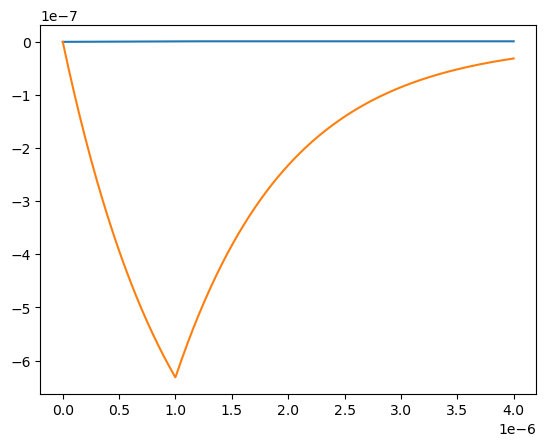

In [1]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Debug = False

class Preamp:
    def __init__(self, R1=10.0e6, C1=1.0e-9, R2=1.0e6, C2=1.0e-12):
        self.r1 = float(R1)
        self.r2 = float(R2)
        self.c1 = float(C1)
        self.c2 = float(C2)
        self.G = C1 / C2
        self.T1 = R1 * C1
        self.T2 = R2 * C2
        self.tmin = 0.0
        self.tmax = 1.0e-6
        self.i0 = 1.0e-12
        
    
    def i_in(self, t):
        if t >= self.tmin and t <= self.tmax:
            return self.i0
        else:
            return 0.0
    
    def rhs(self, t, y):
        if Debug: print(t, y)
        dvin_dt = (self.i_in(t) / self.c1) - y[0] / self.T1
        dvout_dt = -self.G * dvin_dt - y[1] / self.T2
        if Debug: print(t, dvin_dt, dvout_dt)
        return [dvin_dt, dvout_dt]

theAmp = Preamp()

def solver(t, y):
    return theAmp.rhs(t, y)

sol = solve_ivp(solver, [0, 4.0e-6], [0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=1e-8)

plt.plot(sol.t, sol.y[0,:], sol.t, sol.y[1,:])

We see the output voltage build up as the charge flows in and then decayu with a 1 µs time constant once chare stops flowing. This is exactly what we expected.

## Pulse Shaping

Thanks to a lovely set of lecture notes from university of Liverpool, found at 

https://ns.ph.liv.ac.uk/~ajb/ukgs_nis/pre-course-material/lec2-03.pdf

I suspect that we are dealing with something like a CR-RC pulse shaping network, with a circuit like that below, possibly with the extra pole-zero compensation shown dotted.

![Pulse Shaping Network](../PuseShaper.png)

We can continue our differential equation analysis first to understand the new circuit and then to build a comprehensive model of the complete system.

Since this is now a completely voltage driven system and is itself driven by the low-impedance output of the preceding op-amp we don't have to get fancy understanding it. We do have to re-number all the components though so C1 of this circuit becomes C3, $C2\rightarrow{}C4$, the dotted resistor will be R3, $R1\rightarrow{}R4$, and $R2\rightarrow{}R5$. Finally the input voltage here will be V2, the output of the op-amp V3, and the ultimate output V4.

The input current splits between the input capacitor and the compensation resistor so that
$$i_in = (V2 - V3)/R3 + C3\times(dV2/dt - dV3/dt)$$
and it all passes through the solid resistor labeled R1 so
$$\dfrac{V2 - V3}{R3} + C3\times(\dfrac{dV2}{dt} - \dfrac{dV3}{dt}) = \dfrac{V3}{R4}$$

We can then derive the output voltage from V3.
$$\dfrac{V3-V4}{R5} = C4\times{} \dfrac{dV4}{dt}$$
and we can re-write these as equation for the individual time derivatives

$$\dfrac{dV3}{dt}=\dfrac{V2-V3}{R3C3}-\dfrac{V3}{R4C3}+\dfrac{dV2}{dt}$$

$$\dfrac{dV4}{dt}=\dfrac{V3-V4}{R5C4}$$

This time we have three independent parameters, the time constants $\tau_3 = R3C3$, $\tau_4 = R4C3$, and $\tau_5 = R5C4$ and we re-write our equations as 

$$\dfrac{dV3}{dt}=\dfrac{V2-V3}{\tau_3}-\dfrac{V3}{\tau_4}+\dfrac{dV2}{dt}$$

$$\dfrac{dV4}{dt}=\dfrac{V3-V4}{\tau_5}$$

Again, let us write a solver program to explore the system and drive it with some simple pulses.

Here is the program with parameters without pole-zero compensation chosen to make the FWHM 350 ns as in the spec for the CAEN. In the result the blue line is the internal signal V3 and the orange line the output, V4.

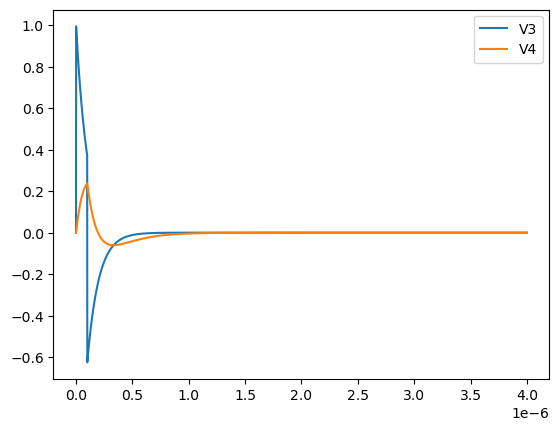

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Debug = False

class Preamp:
    def __init__(self, T3 = 1, T4 = 1e-7, T5 = 2e-7):
        self.T3 = T3
        self.T4 = T4
        self.T5 = T5
        self.tmin = 0.0
        self.tmax = 1.0e-7
        self.tslope = 1.0e-9
        self.V0 = 1.0
        
    # Compute nput voltage at time t
    def V2(self, t):
        if t < self.tslope:
            return t * self.V0 / self.tslope
        elif t < (self.tmax - self.tslope):
            return self.V0
        elif t < self.tmax:
            return (self.tmax - t) * self.V0 / self.tslope
        else:
            return 0.0
    
    # Compute derivative of input voltage at time t
    def DV2(self, t):
        if t < self.tslope:
            return self.V0 / self.tslope
        elif t < (self.tmax - self.tslope):
            return 0.0
        elif t < self.tmax:
            return -self.V0 / self.tslope
        else:
            return 0.0
    
    def rhs(self, t, y):
        if Debug: print(t, y)
        dV3_dt = (self.V2(t) - y[0]) / self.T3 - y[0] / self.T4 + self.DV2(t)
        dV4_dt = (y[0] - y[1]) / self.T5
        if Debug: print(t, dV3_dt, dV4_dt)
        return [dV3_dt, dV4_dt]

theAmp = Preamp()

def solver(t, y):
    return theAmp.rhs(t, y)

sol = solve_ivp(solver, [0, 4.0e-6], [0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=2e-10)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V3')
plt.plot(sol.t, sol.y[1,:], label='V4')
plt.legend()


The input was a 100 ns voltage pulse with 1 ns rise and fall times. Let's try a shorter pulse.

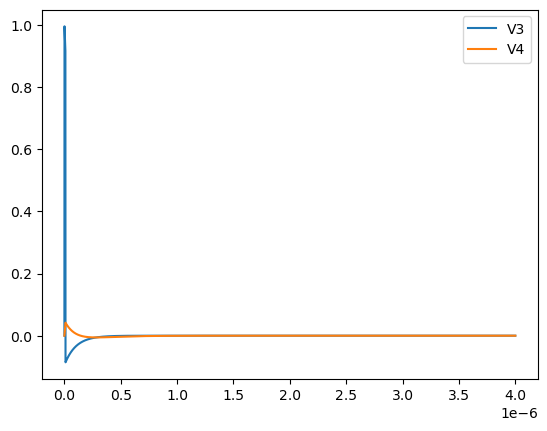

In [4]:
theAmp.tmax = 1.0e-8

sol = solve_ivp(solver, [0, 4.0e-6], [0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=2e-10)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V3')
plt.plot(sol.t, sol.y[1,:], label='V4')
plt.legend()


So we are getting no pulse stretching, only pulse compression. Let's feed it a 2 µs pulse typical of our first stage output.

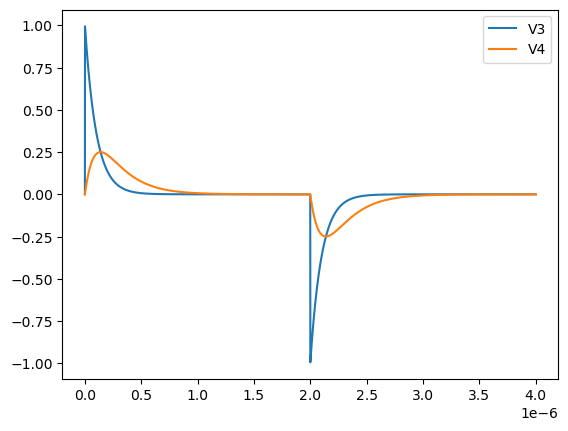

In [5]:
theAmp.tmax = 2.0e-6

sol = solve_ivp(solver, [0, 4.0e-6], [0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=2e-10)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V3')
plt.plot(sol.t, sol.y[1,:], label='V4')
plt.legend()


Well, that is not very helpful. Let's make the time constants longer.

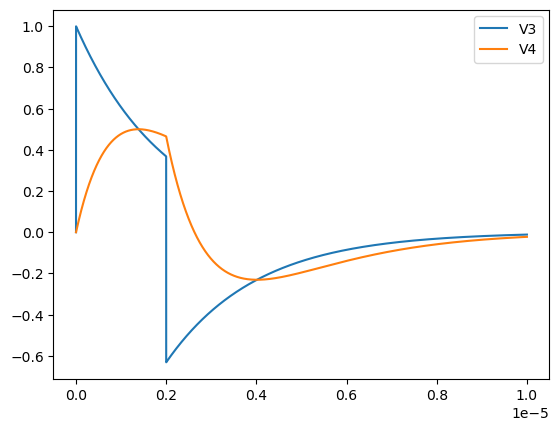

In [8]:
theAmp.tmax = 2.0e-6
theAmp.T4=2e-6
theAmp.T5=1e-6

sol = solve_ivp(solver, [0, 10.0e-6], [0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=2e-10)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V3')
plt.plot(sol.t, sol.y[1,:], label='V4')
plt.legend()


Let's see what giving it some T3 does.

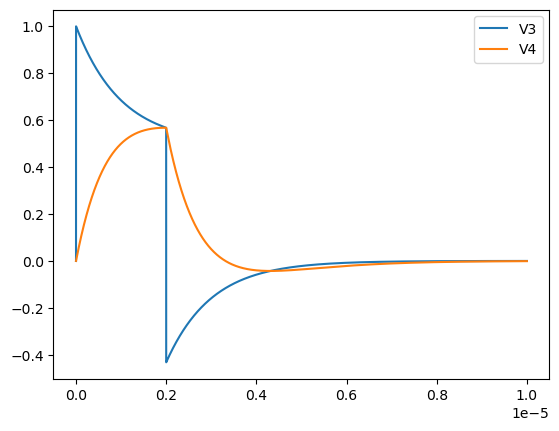

In [9]:
theAmp.T3=2e-6

sol = solve_ivp(solver, [0, 10.0e-6], [0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=2e-10)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V3')
plt.plot(sol.t, sol.y[1,:], label='V4')
plt.legend()

Well, it does what it is supposed to. It decreases the undershoot. That is getting close. What if we connect the two systems together? For this we need to be able to feed the output of the pre-amp into the shaper and the the best way is to extend the equation set and write a new system with all four equations.

The result is VERY encouraging, though the timescale is too long given the datasheet value of 350 ns for the FWHM of the output. Here are the code and result for a 100 ns input current pulse.

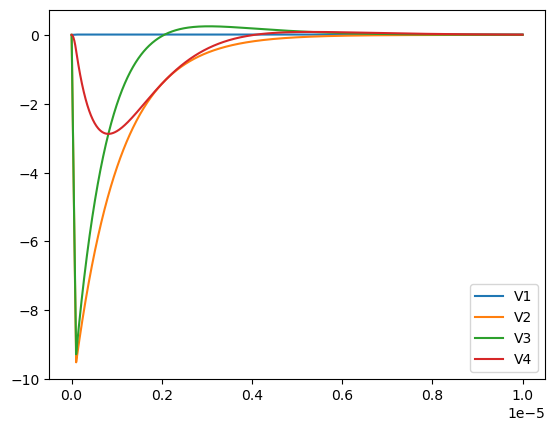

In [10]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Debug = False

class ShapedPreamp:
    def __init__(self, C1=1e-9, G=1000.0, T1=1e-2, T2=1e-6, T3=2e-6, T4=2e-6, T5=1e-6):
        self.c1 = float(C1)
        self.G = float(G)
        self.T1 = float(T1)
        self.T2 = float(T2)
        self.T3 = float(T3)
        self.T4 = float(T4)
        self.T5 = float(T5)
        self.tmin = 0.0
        self.tmax = 1.0e-7
        self.i0 = 1.0e-4
    
    def set_csa_params(self, R1=10.0e6, C1=1.0e-9, R2=1.0e6, C2=1.0e-12):
        self.c2 = float(C2)
        self.G = C1 / C2
        self.T1 = R1 * C1
        self.T2 = R2 * C2
    
    def i_in(self, t):
        if t >= self.tmin and t <= self.tmax:
            return self.i0
        else:
            return 0.0
    
    def rhs(self, t, y):
        if Debug: print(t, y)
        dv1_dt = (self.i_in(t) / self.c1) - y[0] / self.T1
        dv2_dt = -self.G * dv1_dt - y[1] / self.T2
        
        dv3_dt = (y[1] - y[2]) / self.T3 - y[2] / self.T4 + dv2_dt
        dv4_dt = (y[2] - y[3]) / self.T5

        if Debug: print(t, dv1_dt, dv2_dt, dv3_dt, dv4_dt)
        return [dv1_dt, dv2_dt, dv3_dt, dv4_dt]

theAmp = ShapedPreamp()

def solver(t, y):
    return theAmp.rhs(t, y)

sol = solve_ivp(solver, [0, 10.0e-6], [0.0, 0.0, 0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=1e-8)


plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V1')
plt.plot(sol.t, sol.y[1,:], label='V2')
plt.plot(sol.t, sol.y[2,:], label='V3')
plt.plot(sol.t, sol.y[3,:], label='V4')
plt.legend()


We see that the output looks very much right but is rather over long at about 2 µs. Let's reduce the shaper times by a factor of 5.

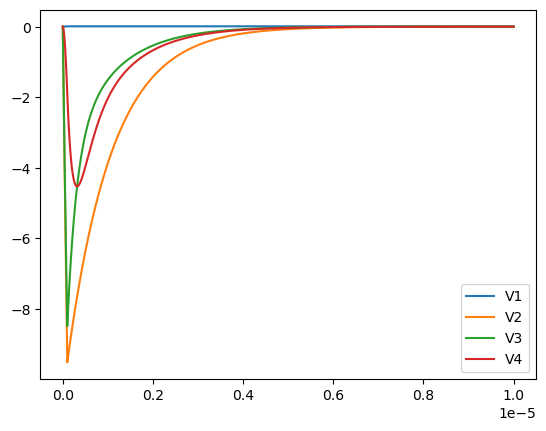

In [12]:
theAmp.T3 = 4e-7
theAmp.T4 = 4e-7
theAmp.T5 = 2e-7

sol = solve_ivp(solver, [0, 10.0e-6], [0.0, 0.0, 0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=1e-8)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V1')
plt.plot(sol.t, sol.y[1,:], label='V2')
plt.plot(sol.t, sol.y[2,:], label='V3')
plt.plot(sol.t, sol.y[3,:], label='V4')
plt.legend()

Oh my, that is much better. I get a FWHM of a little under 1 µs and a time to peak of order 0.3 µs. I think that we need more information on the behavior of the CAEN preamp.

Then I realized that we have that information in the traces that Eliana recorded. I just need to filter them for the very largest ones. Here are 34 of largest from Day3. They have a FWHM of very close to 0.5 µs

![34 largest pulses day 3](../DetectorData/Day3LargestFull.png)

as we can see if we blow up the center section.

![34 largest pulses day 3 zoomed](../DetectorData/Day3LargestZoom.png)

The widths are all extremely close to 0.5 µs but the times to peak vary from 0.25 µs to about 0,4 µs. So our time to peak is in the ball-park but our FWHM is about 2x too large.

Incidentaly, we also get a very good look at the noise by blowing up the first 4.5 µs of the plot, before the pulse starts.

![day 3 noise](../DetectorData/Day3Noise.png)

We see that the noise is pretty much bounded at 17 mV. I can find no excursions outside that range. This should be a help setting trigger conditions in the digitizer. We probably want to set the trigger at about -15 mV.

## Tweaking the pre-amp

What if I tweak the pre-amp parameters a little. Let's try shortening the shaper times even further.

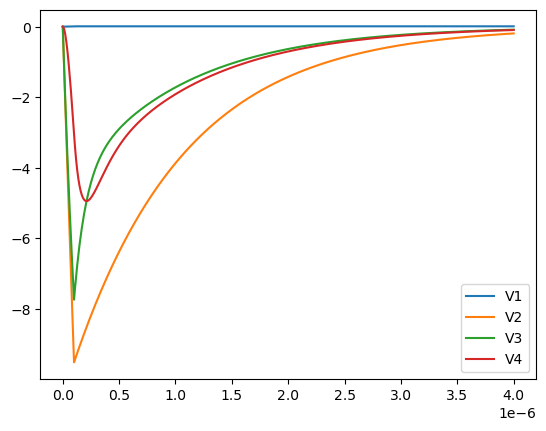

In [13]:
theAmp.T3 = 2e-7
theAmp.T4 = 2e-7
theAmp.T5 = 1e-7

sol = solve_ivp(solver, [0, 4.0e-6], [0.0, 0.0, 0.0, 0.0], rtol=1e-6, atol=1e-10, max_step=1e-8)

plt.figure()
plt.plot(sol.t, sol.y[0,:], label='V1')
plt.plot(sol.t, sol.y[1,:], label='V2')
plt.plot(sol.t, sol.y[2,:], label='V3')
plt.plot(sol.t, sol.y[3,:], label='V4')
plt.legend()

And that is pretty much bang on! We even get the right sort of initial curvature and the overall recory time is quite sensible.

## Pile-up

One thing that we can now investigate is the problem of pile up. We can now simulate two of these pulses ariving with different delay times and see what that does to the trace shape.
